In [139]:
from numpy.polynomial.chebyshev import Chebyshev
import numpy as np
import matplotlib.pyplot as plt
from refnx.reflect import SLD, Slab, ReflectModel
from refnx.analysis import Objective, CurveFitter
from refnx.dataset import Data1D

In [140]:
vfp = np.loadtxt('sld_profile_gradient.txt')
vfp.shape

(2, 500)

In [288]:
from refnx.reflect import Component
from refnx.analysis import possibly_create_parameter, Parameters, Parameter
from numpy.polynomial.chebyshev import Chebyshev, chebpts1

class Cheby(Component):
    _methods = ['direct', 'interp']
    
    def __init__(self, thick, vs, method='direct', order=None, dzf=None, name=None, microslab_max_thickness=1):
        self.name = name
        self._interfaces = None
        
        self.thick = possibly_create_parameter(thick)
        self.method = method
        if method not in ['direct', 'interp']:
            raise ValueError("method must either be 'direct' or 'interp'")

        if isinstance(vs, Parameters):
            self.vs = vs
        else:
            self.vs = Parameters([possibly_create_parameter(v) for v in vs])

        if isinstance(dzf, Parameters):
            self.dzf = dzf
        else:
            if dzf is not None and method == 'interp':
                self.dzf = Parameters([possibly_create_parameter(v) for v in dzf])
                if len(dzf) != len(self.vs) + 1:
                    raise ValueError("len(dzf) must be one larger than len(vs)")
            else:
                self.dzf = None

        try:
            if method == 'interp':
                self.order = int(order)
                
        except TypeError:
            raise TypeError("You must specify a positive integer for 'order' when you use method='interp'")

        self.microslab_max_thickness = microslab_max_thickness

    def _zeds(self):
        if self.dzf is None:
            return self.thick.value * 0.5 * (chebpts1(len(self.vs)) + 1.0)

        zeds = np.cumsum(self.dzf)
        # Normalise dzf to unit interval.
        # clipped to 0 and 1 because we pad on the LHS, RHS later
        # and we need the array to be monotonically increasing
        zeds /= zeds[-1]
        zeds = np.clip(zeds, 0, 1)
        zeds = zeds[0:-1]
        return zeds * self.thick.value

    def slabs(self, structure=None):
        nslabs = int(np.ceil(self.thick.value / self.microslab_max_thickness))
        
        if self.method == "direct":
            cheb = Chebyshev(np.array(self.vs), domain=(0, self.thick.value))
        else:
            zeds = self._zeds()
            cheb = Chebyshev.fit(zeds, np.array(self.vs), domain=(0, self.thick.value), deg=self.order)

        slab_thick = self.thick.value / nslabs
        zed = slab_thick * (np.arange(nslabs) + 0.5)
        rho = cheb(zed)
        slabs = np.zeros((nslabs, 5), float)
        slabs[:, 0] = slab_thick
        slabs[:, 1] = rho
        return slabs
    
    @property
    def parameters(self):
        _p = Parameters([self.thick])
        _p.extend(self.vs)
        if self.dzf is not None:
            _p.extend(self.dzf)
        return _p

In [327]:
si = SLD(2.07)
d2o = SLD(6.36)
sio2 = SLD(3.47)
npnts = 31
# c = Cheby(202, [4, 4, 4, 4, 4, 4, 4, 4, 4], method='interp', order=4)
c = CubicBSpline(202, [4] * npnts, [1/(npnts + 1)] * (npnts + 1))

for p in c.vs:
    p.setp(vary=True, bounds=(3.4, 6.36))
c.thick.setp(vary=True, bounds=(100, 300))

s = si | sio2(10, 3) | c | d2o(0, 3)

In [328]:
c._zeds(), np.array(c.dzf)

(array([  6.3125,  12.625 ,  18.9375,  25.25  ,  31.5625,  37.875 ,
         44.1875,  50.5   ,  56.8125,  63.125 ,  69.4375,  75.75  ,
         82.0625,  88.375 ,  94.6875, 101.    , 107.3125, 113.625 ,
        119.9375, 126.25  , 132.5625, 138.875 , 145.1875, 151.5   ,
        157.8125, 164.125 , 170.4375, 176.75  , 183.0625, 189.375 ,
        195.6875]),
 array([0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125,
        0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125,
        0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125,
        0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125,
        0.03125, 0.03125, 0.03125, 0.03125]))

In [329]:
model = ReflectModel(s)
model.bkg.setp(vary=True, bounds=(0, 1))
data = Data1D('slow_gradient.dat')

In [330]:
objective = Objective(model, data)

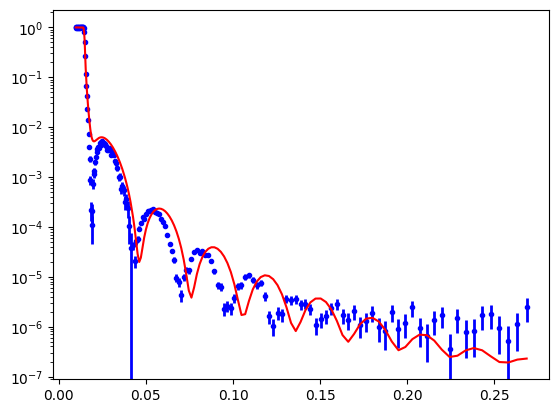

In [331]:
objective.plot()
plt.yscale('log')

In [332]:
fitter = CurveFitter(objective)
fitter.fit('differential_evolution')

-1502.2603843802717: : 473it [13:39,  1.73s/it]


             message: Optimization terminated successfully.
             success: True
                 fun: -1506.541455327575
                   x: [ 3.172e-07  2.277e+02 ...  5.331e+00  4.760e+00]
                 nit: 473
                nfev: 234936
          population: [[ 3.986e-07  2.277e+02 ...  5.325e+00  4.768e+00]
                       [ 3.305e-07  2.244e+02 ...  5.209e+00  4.519e+00]
                       ...
                       [ 3.796e-07  2.293e+02 ...  5.357e+00  4.775e+00]
                       [ 4.893e-07  2.265e+02 ...  5.276e+00  4.351e+00]]
 population_energies: [-1.507e+03 -1.470e+03 ... -1.471e+03 -1.473e+03]
                 jac: [ 1.887e+05  2.087e+00 ...  5.541e+01 -2.865e+01]
               covar: [[ 1.170e-05  3.320e+02 ... -2.076e+02 -1.377e+02]
                       [ 3.320e+02  1.251e+11 ... -4.112e+10 -3.353e+10]
                       ...
                       [-2.076e+02 -4.112e+10 ...  1.911e+10  1.381e+10]
                       [-1.377e+02 

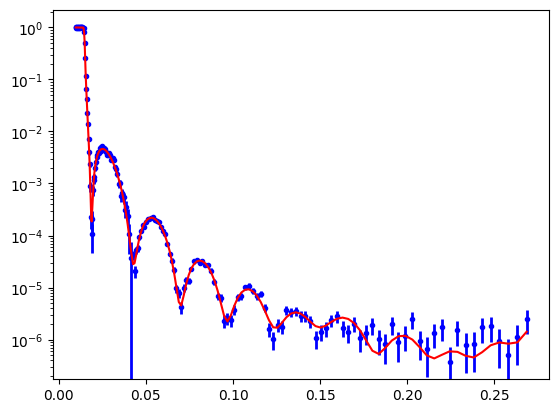

In [333]:
objective.plot()
plt.yscale('log')

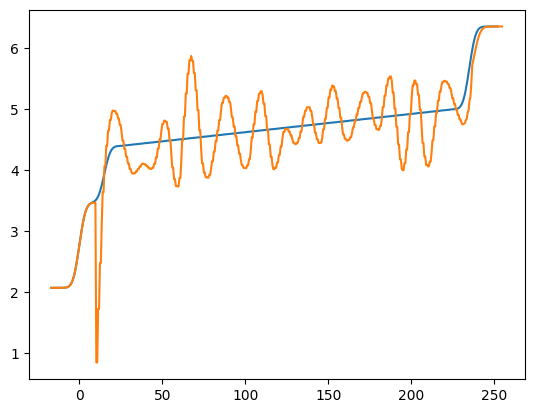

In [335]:
plt.plot(vfp[0], vfp[1])
plt.plot(*s.sld_profile())

In [294]:
class CubicBSpline(Component):
    _methods = ['direct', 'interp']
    
    def __init__(self, thick, vs, dzf=None, name=None, microslab_max_thickness=1):
        self.name = name
        self._interfaces = None
        
        self.thick = possibly_create_parameter(thick)

        if isinstance(vs, Parameters):
            self.vs = vs
        else:
            self.vs = Parameters([possibly_create_parameter(v) for v in vs])

        if isinstance(dzf, Parameters):
            self.dzf = dzf
        else:
            if dzf is not None:
                self.dzf = Parameters([possibly_create_parameter(v) for v in dzf])
                if len(dzf) != len(self.vs) + 1:
                    raise ValueError("len(dzf) must be one larger than len(vs)")
            else:
                self.dzf = None

        self.microslab_max_thickness = microslab_max_thickness

    def _zeds(self):
        if self.dzf is None:
            npnts = len(self.vs)
            return self.thick.value / npnts * (np.arange(npnts) + 0.5)

        zeds = np.cumsum(self.dzf)
        # Normalise dzf to unit interval.
        # clipped to 0 and 1 because we pad on the LHS, RHS later
        # and we need the array to be monotonically increasing
        zeds /= zeds[-1]
        zeds = np.clip(zeds, 0, 1)
        zeds = zeds[0:-1]
        return zeds * self.thick.value

    def slabs(self, structure=None):
        nslabs = int(np.ceil(self.thick.value / self.microslab_max_thickness))
        zeds = self._zeds()
        
        bspl = make_interp_spline(zeds, np.array(self.vs)) 

        slab_thick = self.thick.value / nslabs
        zed = slab_thick * (np.arange(nslabs) + 0.5)
        rho = bspl(zed)
        slabs = np.zeros((nslabs, 5), float)
        slabs[:, 0] = slab_thick
        slabs[:, 1] = rho
        return slabs
    
    @property
    def parameters(self):
        _p = Parameters([self.thick])
        _p.extend(self.vs)
        if self.dzf is not None:
            _p.extend(self.dzf)
        return _p

In [286]:
bspl = make_interp_spline(x, [1,2,3,4,5,4.5])

In [282]:
x
xx = np.linspace(-200, 200, 101)

In [283]:
bspl(-200)

array(1.40625)

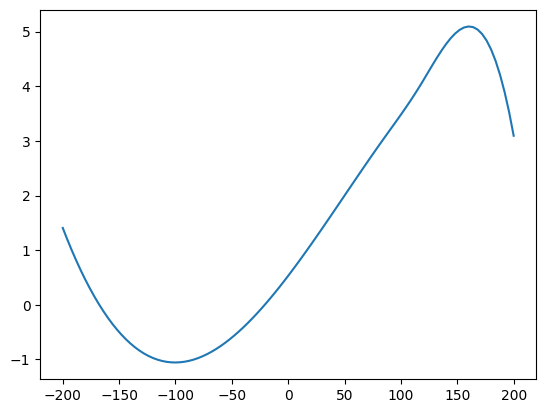

In [284]:
plt.plot(xx, bspl(xx))

In [313]:
dzf = [0.25, 0.25, 0.25, 0.25]
zeds = np.cumsum(dzf)
print(zeds)
# Normalise dzf to unit interval.
# clipped to 0 and 1 because we pad on the LHS, RHS later
# and we need the array to be monotonically increasing
zeds /= zeds[-1]
zeds = np.clip(zeds, 0, 1)
zeds = zeds[0:-1]
zeds * 100

[0.25 0.5  0.75 1.  ]


array([25., 50., 75.])

In [338]:
import scipy.special, numpy as np

In [339]:
print(scipy.special.eval_hermite(np.arange(2), np.zeros((1,2), dtype=int)))

[[1. 0.]]


In [340]:
np.version.version

'1.26.4'